<a href="https://colab.research.google.com/github/priyanka287-agrawal/priyanka287-agrawal/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

# **PROJECT TOPIC**
Developed a hybrid air quality forecasting system using Random Forest, XGBoost, and LSTM integrated with ARIMA-based residual modeling, achieving improved AQI prediction accuracy through combined linear and non-linear pattern learning.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correct file path (remove extra space)
file_path = "/cityday_filled_SO2.xlsx"

# Load the Excel file first
df = pd.read_excel(file_path)

# Show the first 5 rows
print(df.head())


# Filter for Patna city
patna_df = df[df['City'] == 'Patna'].copy() # Add .copy() to avoid SettingWithCopyWarning

# Select the 'PM2.5' column
patna_pm10 = patna_df['O3'].copy() # Select PM10 and make a copy

# Display the first few values of the filtered PM10 data
print(patna_pm10.head())

# update NAN to values of autoregression (ARMA)
c=3
phi_1=0.4
phi_2=0.5
theta_1=0.2
np.random.seed(42)
errors = np.random.normal(0, 5, len(patna_pm10))

# Check if the series has at least two elements before setting the first two values
if len(patna_pm10) > 1:
    patna_pm10.iloc[0] = 1.8
    patna_pm10.iloc[1] = 9.69
elif len(patna_pm10) == 1:
     patna_pm10.iloc[0] = 1.8 # Only set the first if there's only one element


# applying the provided formula to all values
for i in range(len(patna_pm10)):
  if np.isnan(patna_pm10.iloc[i]):
        if i >= 2: # Ensure there are at least two previous values for phi_1 and phi_2
            patna_pm10.iloc[i] = c + phi_1 * patna_pm10.iloc[i-1] + phi_2 * patna_pm10.iloc[i-2] + theta_1 * errors[i-1]+ errors[i]
        elif i == 1: # For the second element, only phi_1 and theta_1 apply
             patna_pm10.iloc[i] = c + phi_1 * patna_pm10.iloc[i-1] + theta_1 * errors[i-1] + errors[i]
        else: # For the first element, only c and error apply
             patna_pm10.iloc[i] = c + errors[i]

# after generating patna_pm10 (pandas Series)
# replace negatives with small positive value (or 0)
#patna_pm10 = patna_pm10.clip(lower=0.1)   # keeps values >= 0.1
# update original df as before
df.loc[patna_df.index, 'O3'] = patna_pm10


# Save to new file
df.to_excel("cityday_filled_O3.xlsx", index=False)

# Display the first few values of the modified PM10 data
print("\nPM2.5 column after applying formula:")
print(patna_pm10.head())

print(patna_pm10.describe())
plt.plot(patna_pm10.values)
plt.title('Patna PM10 (after generation)')
plt.show()


In [ ]:
import pandas as pd

# Replace with your actual file path
file_path = "/cityday_filled_pm10 .xlsx"

# Show the first 5 rows
print(df.head())

In [ ]:
from google.colab import files

files.download("cityday_filled_O3.xlsx")

In [ ]:
!pip install pmdarima


## Define `apply_arima_filling` function

This function will use `pmdarima.auto_arima` to automatically select the best ARIMA model parameters and fill missing values in a given time series. This ensures the function is available for subsequent calls.

## Verify DataFrame Column Data Types

To identify the non-numeric column causing the `TypeError`, let's display the `info()` and `dtypes` of the DataFrame.

In [ ]:
print('DataFrame Info:')
df.info()

print('\nDataFrame dtypes:')
print(df.dtypes)

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/merged_p2.5.xlsx")

#selct relevant numeric columns
column_to_compare=['rkpuram','igi','punjabi','lodhi_road','chandni_chowk','rohini','dwarka','patna','anand']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between merged_pm2.5")
plt.show()



In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/BR005_FILLED_AQI.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)','NOx (ppb)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/DL030_FILLED_2023_AQI_NEW.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)','NOx (ug/m3)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/DL024_FILLED_2023_AQI_NEW.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)','NOx (ppb)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#load the file - Make sure this path is correct for your data until 2023
file_path = "/DL024.csv" # Please ensure this file contains data up to 2023
df=pd.read_csv(file_path)

# Convert 'From Date' and 'To Date' to datetime objects
df['From Date'] = pd.to_datetime(df['From Date'], errors='coerce', format='mixed')
df['To Date'] = pd.to_datetime(df['To Date'], errors='coerce', format='mixed')

# Check the date range of the loaded data
print("Date range of the loaded data:")
print(f"Start Date: {df['From Date'].min()}")
print(f"End Date: {df['To Date'].max()}")

# Select the columns to interpolate
columns_to_interpolate = ['NO2 (ug/m3)']

# Perform linear interpolation on the selected columns and clip negative values to 0
for col in columns_to_interpolate:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear',order=1).clip(lower=0)
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")


# Save to new file
df.to_excel("DL030.xlsx", index=False)

# Display the first few values of the modified data for each interpolated column
print("\nFirst 5 rows after interpolation:")
print(df[columns_to_interpolate].head())

# Display descriptive statistics and plot for each interpolated column
for col in columns_to_interpolate:
    if col in df.columns:
        print(f"\nDescription for {col}:")
        print(df[col].describe())
        plt.figure(figsize=(10, 4))
        plt.plot(df['From Date'], df[col].values)
        plt.title(f'{col} after interpolation')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.show()

In [ ]:
!pip install pmdarima

### Example of Polynomial Interpolation with `order`

This code snippet demonstrates how to apply polynomial interpolation of `order=2` to a specific column named `BP (mmHg)`. You can change the `order` to `1`, `3`, or any other suitable integer depending on the desired polynomial degree.

In [ ]:
from google.colab import files

files.download("DL030.xlsx")


In [ ]:
from csv import excel
import pandas as pd
file_path="/DL030_FILLED_2023.xlsx"
df=pd.read_excel(file_path)
# CPCB AQI breakpoints for pollutants
breakpoints = {
    "PM2.5 (ug/m3)": [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 500, 401, 500)
    ],

    "PM10 (ug/m3)": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],

    "NO2 (ug/m3)": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 1000, 401, 500)
    ],

    "SO2 (ug/m3)": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 3600, 401, 500)
    ],

    "Ozone (ug/m3)": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ],

    "CO (mg/m3)": [
        (0, 1, 0, 50),
        (1.1, 2, 51, 100),
        (2.1, 10, 101, 200),
        (10.1, 17, 201, 300),
        (17.1, 34, 301, 400),
        (34.1, 50, 401, 500)
    ]
}

def compute_subindex(pollutant, concentration):
    if pollutant not in breakpoints or pd.isna(concentration):
        return None

    for BP_low, BP_high, I_low, I_high in breakpoints[pollutant]:
        if BP_low <= concentration <= BP_high:
            # Apply AQI formula
            aqi = ((I_high - I_low) / (BP_high - BP_low)) * (concentration - BP_low) + I_low
            return round(aqi)

    return None  # If not in any range


pollutants = ["PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO2 (ug/m3)", "SO2 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)"]

for p in pollutants:
    if p in df.columns:
        df[f"AQI_{p}"] = df[p].apply(lambda x: compute_subindex(p, x))
    else:
        df[f"AQI_{p}"] = None

# Final AQI = max of sub-indices
df["AQI_Final"] = df[[f"AQI_{p}" for p in pollutants]].max(axis=1)

# --- Start of new code to count and fill NaNs in AQI columns ---

aqi_columns = [f"AQI_{p}" for p in pollutants] + ["AQI_Final"]

print("\n--- NaN counts BEFORE interpolation for AQI columns ---")
print(df[aqi_columns].isnull().sum())

# Apply linear interpolation to all AQI columns
for col in aqi_columns:
    df[col] = df[col].interpolate(method='linear')

print("\n--- NaN counts AFTER interpolation for AQI columns ---")
print(df[aqi_columns].isnull().sum())

# --- End of new code ---

#save the file
df.to_excel("DL030_FILLED_AQI_2023.xlsx", index=False)
df.head()


In [ ]:
from google.colab import files

files.download("DL030_FILLED_AQI_2023.xlsx")


In [ ]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import datetime as dt
import plotly.io as pio
import plotly.express as px
#reading the dataset and storing it as a dataframe
file_path="/DL030_FILLED_2023_AQI_NEW.xlsx"
df=pd.read_excel(file_path)



#changing column names so that they don't have white-spaces, numbers, or any special-characters
df.rename(columns={
    'From Date': 'from_date',
    'To Date': 'to_date',
    'PM2.5 (ug/m3)': 'PM2.5',
    'PM10 (ug/m3)': 'PM10',
    'NO (ug/m3)': 'NO',
    'NO2 (ug/m3)': 'NO2',
    'NOx (ug/m3)': 'NOx',
    'NH3 (ug/m3)': 'NH3',
    'SO2 (ug/m3)': 'SO2',
    'CO (mg/m3)': 'CO',
    'Ozone (ug/m3)': 'Ozone'
}, inplace=True)

# Convert 'from_date' to datetime objects
df['from_date'] = pd.to_datetime(df['from_date'], errors='coerce')

# List of pollutant columns to interpolate
pollutant_columns_to_interpolate = ['PM2.5','PM10','NO','NO2','NOx','NH3','SO2','CO','Ozone']

# Apply linear interpolation to pollutant columns
for col in pollutant_columns_to_interpolate:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear')

#extracting the 'Month' from the Date
df['Month'] = df['from_date'].dt.month

#creating a new column 'MonthNumber' by converting the 'Month' column values to integers
df['MonthNumber'] = df['Month'].apply(lambda x: int(x))

#creating a new column 'MonthName' by converting the 'MonthNumber' column values to the monthNames
df['MonthName'] = df['MonthNumber'].apply(lambda x: calendar.month_abbr[x])
#extracting the 'Year' from the date
df['Year'] = df['from_date'].dt.year
#grouping by 'MonthName' and finding mean values for the numerical columns
regionStats = df.groupby(['Year','MonthName'])[['PM2.5','PM10','NO','NO2','NOx','NH3','SO2','CO','Ozone']].mean().reset_index()


regionStats = regionStats.sort_values(['Year', 'MonthName'])

In [ ]:
yearly_avg = regionStats_long.groupby(
    ['Year', 'Pollutant'], as_index=False
)['Concentration'].mean()

plt.figure(figsize=(15, 7))

sns.barplot(
    data=yearly_avg,
    x='Year',
    y='Concentration',
    hue='Pollutant'
)

plt.title('Year-wise Average Pollutant Concentration')
plt.xlabel('Year')
plt.ylabel('Average Concentration')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


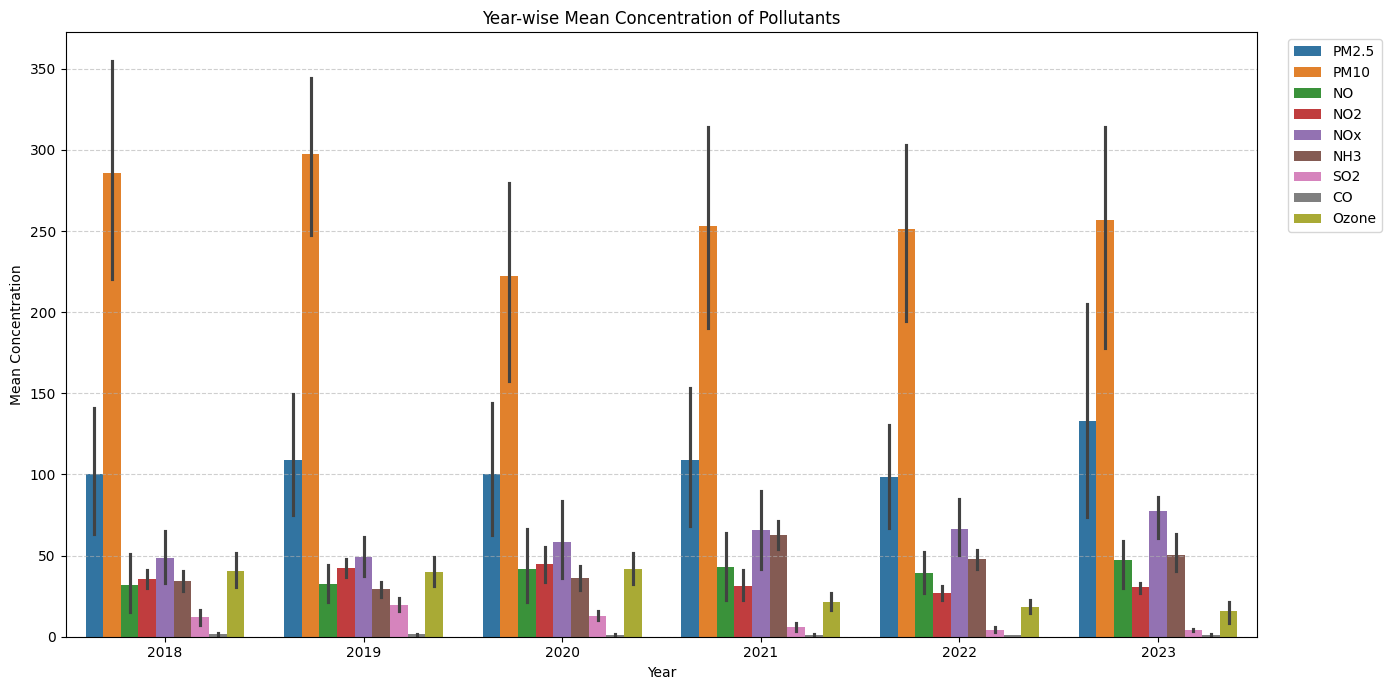

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the regionStats DataFrame to a long format
regionStats_long = regionStats.melt(
    id_vars=['Year'],
    value_vars=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone'],
    var_name='Pollutant',
    value_name='MeanConcentration'
)
plt.figure(figsize=(14, 7))

sns.barplot(
    data=regionStats_long,
    x='Year',
    y='MeanConcentration',
    hue='Pollutant'
)

plt.title('Year-wise Mean Concentration of Pollutants')
plt.xlabel('Year')
plt.ylabel('Mean Concentration')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone']

for pollutant in pollutants:
    fig = px.bar(regionStats,
                 x='MonthName',
                 y=pollutant,
                 color='Year',
                 barmode='group',
                 title=f'Average {pollutant} Concentration Month-wise',
                 labels={'MonthName': 'Month', pollutant: f'Average {pollutant} Concentration'},
                 category_orders={'MonthName': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']}
                 )
    fig.show()

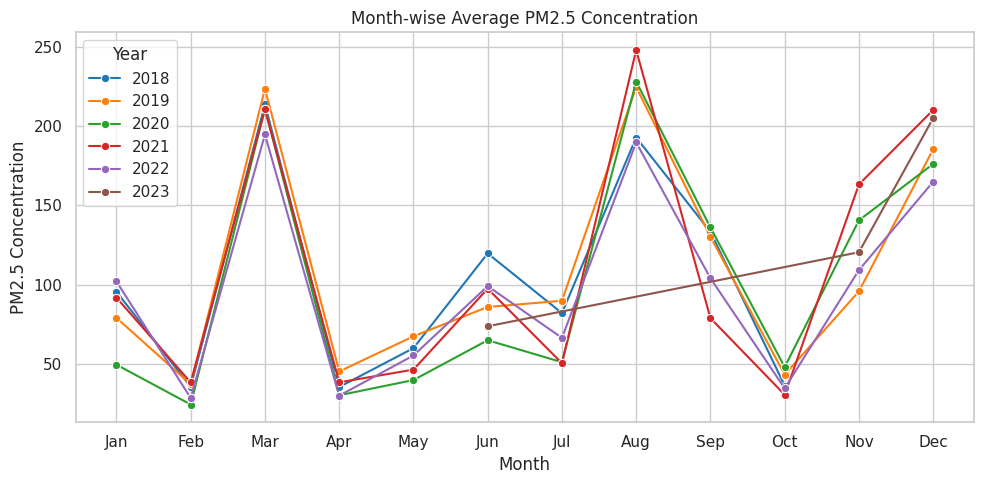

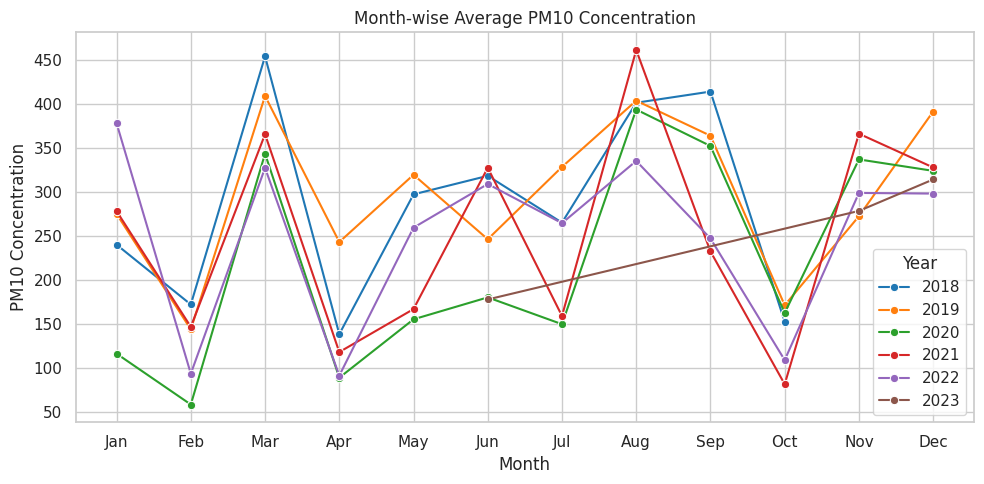

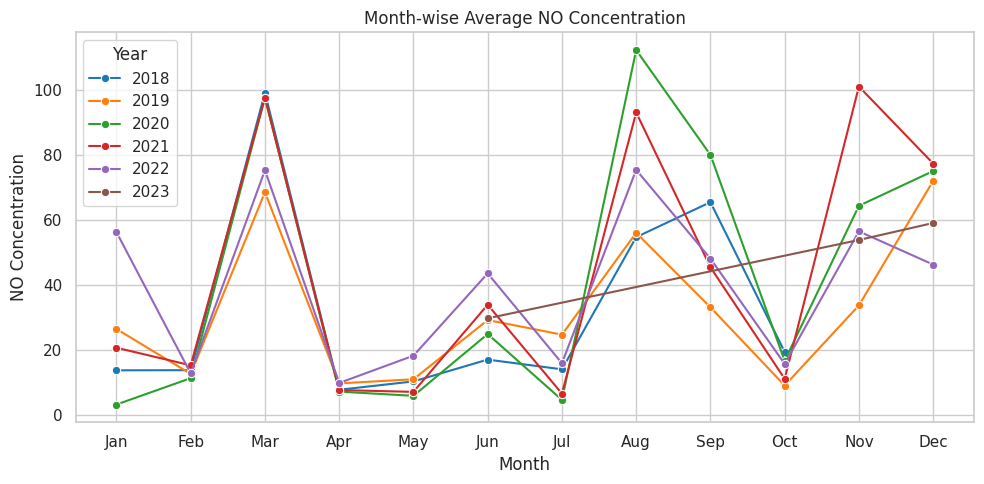

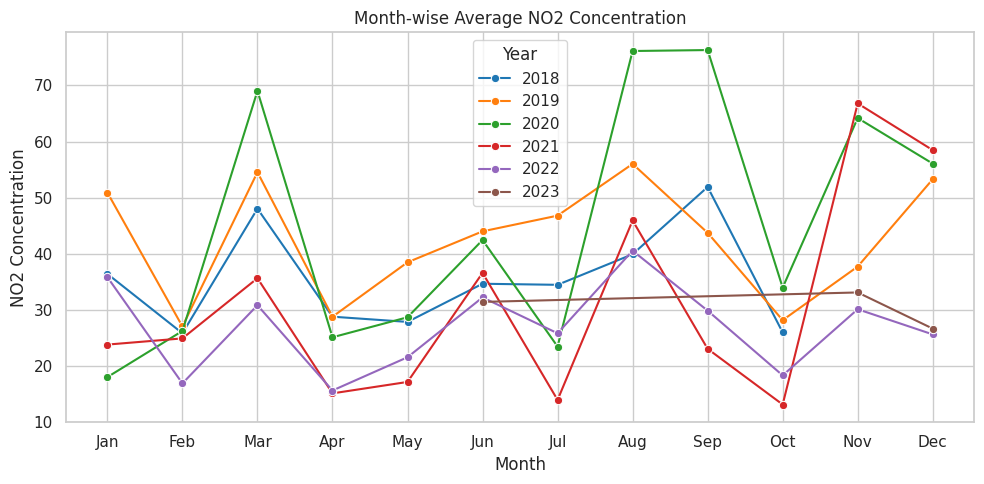

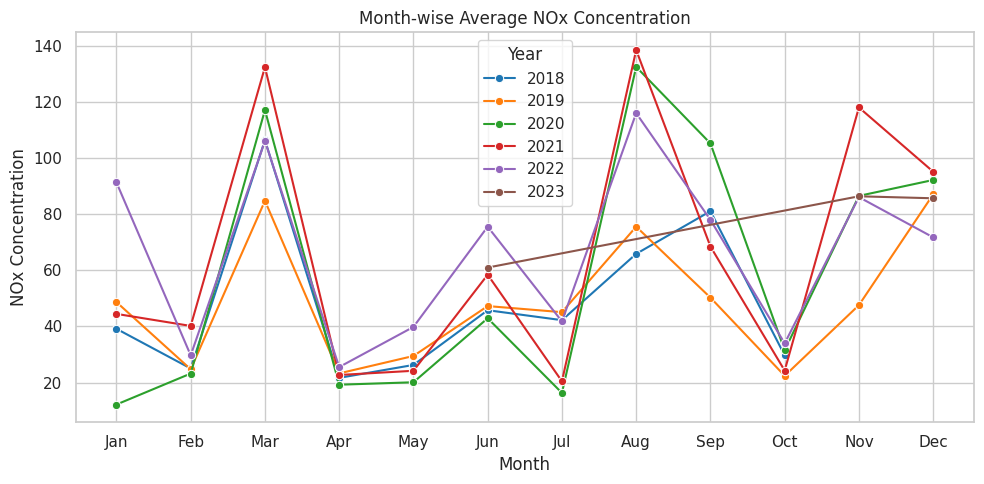

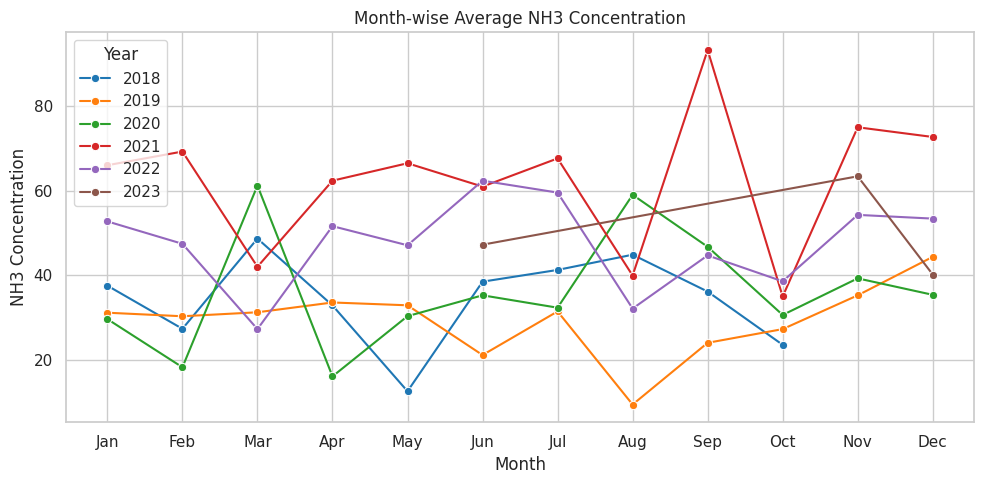

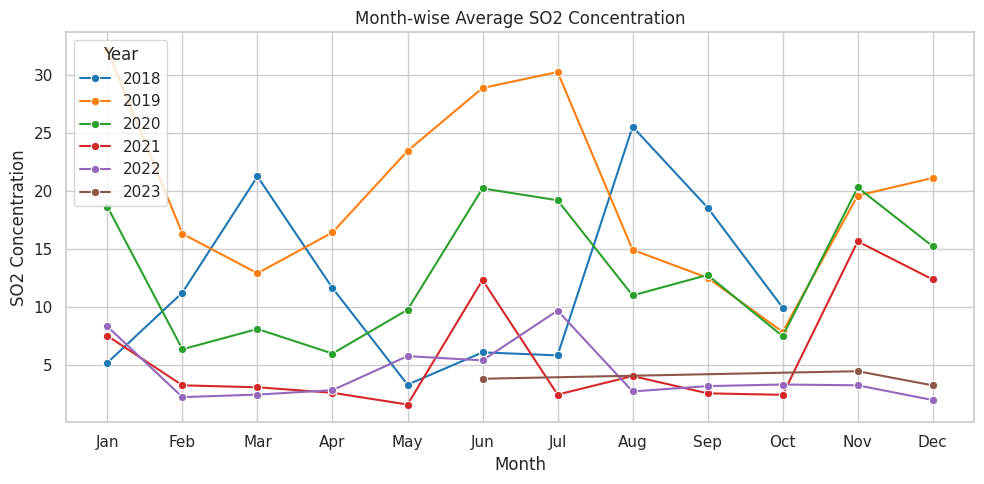

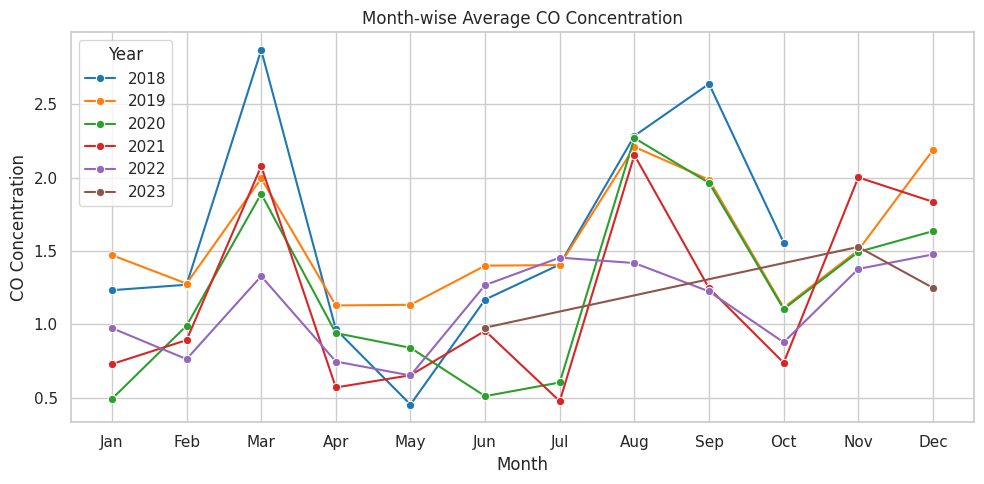

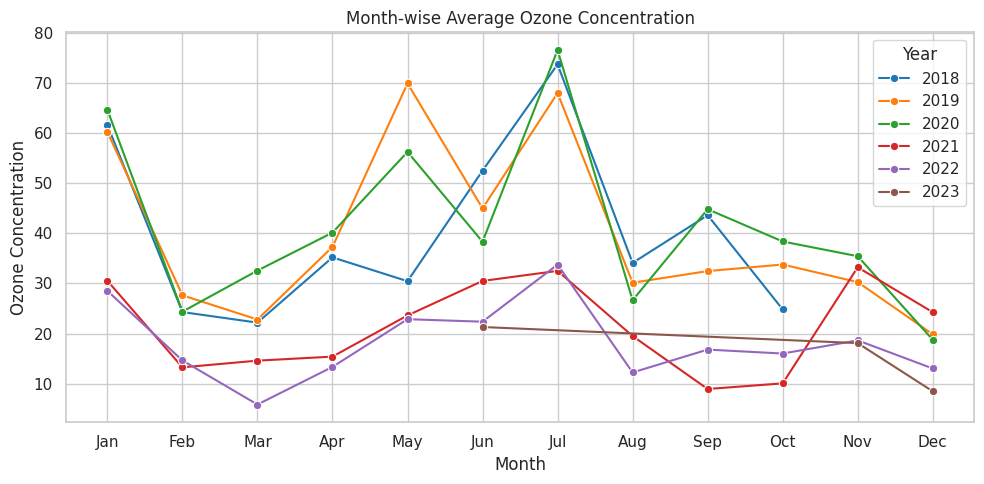

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for pollutant in ['PM2.5','PM10','NO','NO2','NOx','NH3','SO2','CO','Ozone']:
    plt.figure(figsize=(10,5))

    sns.lineplot(
        data=regionStats,
        x='MonthName',
        y=pollutant,
        hue='Year',
        marker='o',
        palette='tab10',
        hue_order=sorted(regionStats['Year'].unique())
    )

    plt.xticks(ticks=range(12), labels=month_order)
    plt.title(f'Month-wise Average {pollutant} Concentration')
    plt.xlabel('Month')
    plt.ylabel(f'{pollutant} Concentration')
    plt.tight_layout()
    plt.show()


In [ ]:
from google.colab import files
files.download("future_pollution_with_aqi_xg_predictions.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

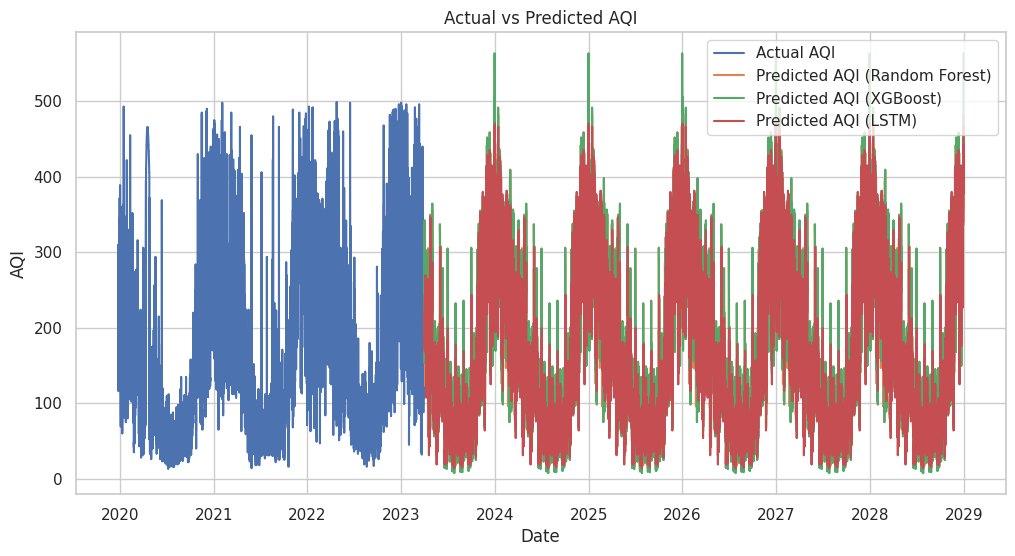

In [ ]:
#graph
import pandas as pd
import matplotlib.pyplot as plt

# Original data (till 3rd April 2023)
original_data = pd.read_excel("/BR005_FILLED_AQI _2023.xlsx")

# Predicted data (4th April 2023 onwards)
predicted_data = pd.read_excel("/final_pollution_with_cpcb_aqi(br005).xlsx")

# standardize the date time
original_data['Date'] = pd.to_datetime(original_data['From Date'])
predicted_data['Date'] = pd.to_datetime(predicted_data['From Date'])

#compare only required original aqi with multiple predicted aqi
original_data = original_data[['Date', 'AQI_Final']]
predicted_data = predicted_data[['Date','AQI_CPCB','AQI_RF','AQI_LSTM']]

#rename
original_data.rename(columns={'AQI_Final': 'Actual_AQI'}, inplace=True)
predicted_data.rename(columns={'AQI_RF':'Predicted_rf','AQI_CPCB':'Predicted_xgb','AQI_LSTM': 'Predicted_lstm'}, inplace=True)

#combined columns
combined_data = pd.concat([original_data, predicted_data], ignore_index=True)

# Sort by date
combined_data = combined_data.sort_values(by='Date')
#graphs for comparison between aqi
plt.figure(figsize=(12,6))

plt.plot(combined_data['Date'], combined_data['Actual_AQI'], label='Actual AQI')
plt.plot(combined_data['Date'], combined_data['Predicted_rf'], label='Predicted AQI (Random Forest)')
plt.plot(combined_data['Date'], combined_data['Predicted_xgb'], label='Predicted AQI (XGBoost)')
plt.plot(combined_data['Date'], combined_data['Predicted_lstm'], label='Predicted AQI (LSTM)')

plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()

plt.show()

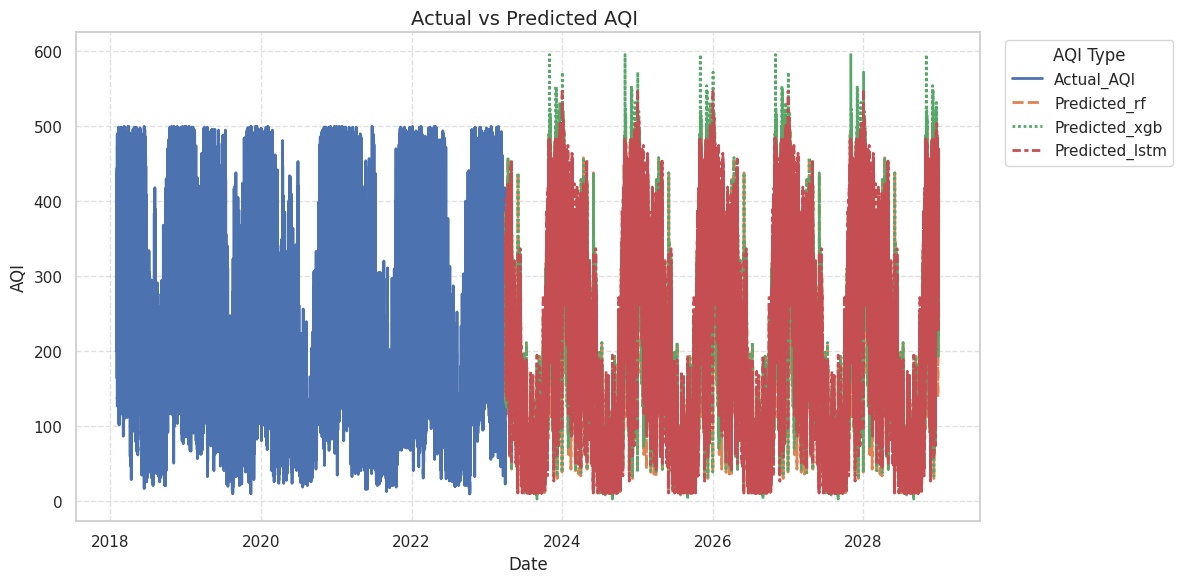

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Original data (till 3rd April 2023)
original_data = pd.read_excel("/DL024_FILLED_2023_AQI_NEW.xlsx")

# Predicted data (4th April 2023 onwards)
predicted_data = pd.read_excel("//final_pollution_with_cpcb_aqi (dl024).xlsx")

# standardize the date time
original_data['Date'] = pd.to_datetime(original_data['From Date'])
predicted_data['Date'] = pd.to_datetime(predicted_data['From Date'])

#compare only required original aqi with multiple predicted aqi
original_data = original_data[['Date', 'AQI_Final']]
predicted_data = predicted_data[['Date','AQI_CPCB','AQI_RF','AQI_LSTM']]

#rename
original_data.rename(columns={'AQI_Final': 'Actual_AQI'}, inplace=True)
predicted_data.rename(columns={'AQI_RF':'Predicted_rf','AQI_CPCB':'Predicted_xgb','AQI_LSTM': 'Predicted_lstm'}, inplace=True)

#combined columns
combined_data = pd.concat([original_data, predicted_data], ignore_index=True)

# Sort by date
combined_data = combined_data.sort_values(by='Date')

# Define rolling window size
window_size = 7


# Melt the DataFrame for easier plotting with different line styles
combined_melted = combined_data.melt(
    id_vars=['Date'],
    value_vars=['Actual_AQI', 'Predicted_rf', 'Predicted_xgb', 'Predicted_lstm'],
    var_name='AQI_Type',
    value_name='AQI_Value'
)

# Set the style for the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=combined_melted,
    x='Date',
    y='AQI_Value',
    hue='AQI_Type',
    style='AQI_Type', # Use 'style' to differentiate line patterns for different AQI types
    linewidth=2, # Increase line width for better visibility
    palette='deep' # Use a distinct color palette
)

plt.title(f'Actual vs Predicted AQI ', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.legend(title='AQI Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download("/future_pollution_with_aqi_trial(dl030).xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel("/BR005_FILLED_AQI _2023.xlsx")

df['From Date'] = pd.to_datetime(df['From Date'])

# ==============================
# 2. CREATE TIME FEATURES
# ==============================
df['year'] = df['From Date'].dt.year
df['month'] = df['From Date'].dt.month
df['day'] = df['From Date'].dt.day
df['hour'] = df['From Date'].dt.hour

# ==============================
# 3. DEFINE POLLUTANTS
# ==============================
pollutants = [
    "PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO2 (ug/m3)",
    "SO2 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)"
]

features = ['year', 'month', 'day', 'hour']

# ==============================
# 4. TRAIN XGBOOST MODELS
# ==============================
models = {}

for col in pollutants:
    model = XGBRegressor(n_estimators=200, max_depth=5)
    model.fit(df[features], df[col])
    models[col] = model

# ==============================
# 5. CREATE FUTURE TIME RANGE
# ==============================
future_dates = pd.date_range(
    start="2023-04-02",
    end="2028-12-31",
    freq="H"
)

future_df = pd.DataFrame()
future_df['From Date'] = future_dates

# Create features
future_df['year'] = future_df['From Date'].dt.year
future_df['month'] = future_df['From Date'].dt.month
future_df['day'] = future_df['From Date'].dt.day
future_df['hour'] = future_df['From Date'].dt.hour

# ==============================
# 6. PREDICT POLLUTANTS
# ==============================
for col in pollutants:
    future_df[col] = models[col].predict(future_df[features])

# Remove negative values
for col in pollutants:
    future_df[col] = future_df[col].clip(lower=0)
    # ==============================
# 7. RANDOM FOREST AQI
# ==============================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(df[pollutants], df['AQI_Final'])

future_df['AQI_RF'] = rf_model.predict(future_df[pollutants])
future_df['AQI_RF'] = future_df['AQI_RF'].clip(lower=10)

# ==============================
# 8. LSTM AQI
# ==============================
clean_data = df[pollutants + ['AQI_Final']].dropna()

input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

scaled_X = input_scaler.fit_transform(clean_data[pollutants])
scaled_y = output_scaler.fit_transform(clean_data[['AQI_Final']])

combined = np.hstack((scaled_X, scaled_y))

def create_seq(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, :-1])
        y.append(data[i+window, -1])
    return np.array(X), np.array(y)

X_seq, y_seq = create_seq(combined, 24)

split = int(0.8 * len(X_seq))
X_train, y_train = X_seq[:split], y_seq[:split]

model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

scaled_future = input_scaler.transform(future_df[pollutants])

future_seq = []
for i in range(len(scaled_future) - 24):
    future_seq.append(scaled_future[i:i+24])

future_seq = np.array(future_seq)

lstm_pred = model_lstm.predict(future_seq)
lstm_pred = output_scaler.inverse_transform(lstm_pred)

future_df['AQI_LSTM'] = np.nan
future_df.loc[future_df.index[-len(lstm_pred):], 'AQI_LSTM'] = lstm_pred.flatten()
future_df['AQI_LSTM'] = future_df['AQI_LSTM'].clip(lower=10)


# ==============================
# 7. CPCB SUB-INDEX FUNCTION
# ==============================
def sub_index(c, I_lo, I_hi, BP_lo, BP_hi):
    return ((I_hi - I_lo) / (BP_hi - BP_lo)) * (c - BP_lo) + I_lo

# ==============================
# 8. POLLUTANT BREAKPOINT FUNCTIONS
# ==============================

def pm25_index(c):
    if c <= 30: return sub_index(c, 0, 50, 0, 30)
    elif c <= 60: return sub_index(c, 51, 100, 31, 60)
    elif c <= 90: return sub_index(c, 101, 200, 61, 90)
    elif c <= 120: return sub_index(c, 201, 300, 91, 120)
    elif c <= 250: return sub_index(c, 301, 400, 121, 250)
    else: return sub_index(c, 401, 500, 251, 500)

def pm10_index(c):
    if c <= 50: return sub_index(c, 0, 50, 0, 50)
    elif c <= 100: return sub_index(c, 51, 100, 51, 100)
    elif c <= 250: return sub_index(c, 101, 200, 101, 250)
    elif c <= 350: return sub_index(c, 201, 300, 251, 350)
    elif c <= 430: return sub_index(c, 301, 400, 351, 430)
    else: return sub_index(c, 401, 500, 431, 600)

def no2_index(c):
    if c <= 40: return sub_index(c, 0, 50, 0, 40)
    elif c <= 80: return sub_index(c, 51, 100, 41, 80)
    elif c <= 180: return sub_index(c, 101, 200, 81, 180)
    elif c <= 280: return sub_index(c, 201, 300, 181, 280)
    elif c <= 400: return sub_index(c, 301, 400, 281, 400)
    else: return sub_index(c, 401, 500, 401, 500)

def so2_index(c):
    if c <= 40: return sub_index(c, 0, 50, 0, 40)
    elif c <= 80: return sub_index(c, 51, 100, 41, 80)
    elif c <= 380: return sub_index(c, 101, 200, 81, 380)
    elif c <= 800: return sub_index(c, 201, 300, 381, 800)
    elif c <= 1600: return sub_index(c, 301, 400, 801, 1600)
    else: return sub_index(c, 401, 500, 1601, 2000)

def co_index(c):
    if c <= 1: return sub_index(c, 0, 50, 0, 1)
    elif c <= 2: return sub_index(c, 51, 100, 1.1, 2)
    elif c <= 10: return sub_index(c, 101, 200, 2.1, 10)
    elif c <= 17: return sub_index(c, 201, 300, 10.1, 17)
    elif c <= 34: return sub_index(c, 301, 400, 17.1, 34)
    else: return sub_index(c, 401, 500, 34.1, 50)

def o3_index(c):
    if c <= 50: return sub_index(c, 0, 50, 0, 50)
    elif c <= 100: return sub_index(c, 51, 100, 51, 100)
    elif c <= 168: return sub_index(c, 101, 200, 101, 168)
    elif c <= 208: return sub_index(c, 201, 300, 169, 208)
    elif c <= 748: return sub_index(c, 301, 400, 209, 748)
    else: return sub_index(c, 401, 500, 749, 1000)

# ==============================
# 9. CALCULATE SUB-INDICES
# ==============================
future_df['PM2.5_index'] = future_df["PM2.5 (ug/m3)"].apply(pm25_index)
future_df['PM10_index'] = future_df["PM10 (ug/m3)"].apply(pm10_index)
future_df['NO2_index'] = future_df["NO2 (ug/m3)"].apply(no2_index)
future_df['SO2_index'] = future_df["SO2 (ug/m3)"].apply(so2_index)
future_df['CO_index'] = future_df["CO (mg/m3)"].apply(co_index)
future_df['O3_index'] = future_df["Ozone (ug/m3)"].apply(o3_index)

# ==============================
# 10. FINAL AQI (CPCB METHOD)
# ==============================
future_df['AQI_CPCB'] = future_df[
    ['PM2.5_index', 'PM10_index', 'NO2_index',
     'SO2_index', 'CO_index', 'O3_index']
].max(axis=1)

# ==============================
# 11. SAVE OUTPUT
# ==============================
future_df.to_excel("final_pollution_with_cpcb_aqi.xlsx", index=False)

print("✅ DONE: Pollutants + CPCB AQI saved successfully!")

/tmp/ipykernel_19152/1820778582.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
✅ DONE: Pollutants + CPCB AQI saved successfully!


In [ ]:
from google.colab import files
files.download("final_pollution_with_cpcb_aqi.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45230 entries, 0 to 45229
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   From Date          45230 non-null  datetime64[ns]
 1   To Date            45230 non-null  datetime64[ns]
 2   PM2.5 (ug/m3)      45230 non-null  float64       
 3   PM10 (ug/m3)       45230 non-null  float64       
 4   NO (ug/m3)         45230 non-null  float64       
 5   NO2 (ug/m3)        45230 non-null  float64       
 6   NOx (ppb)          45230 non-null  float64       
 7   NH3 (ug/m3)        45230 non-null  float64       
 8   SO2 (ug/m3)        45230 non-null  float64       
 9   CO (mg/m3)         45230 non-null  float64       
 10  Ozone (ug/m3)      45230 non-null  float64       
 11  Benzene (ug/m3)    45230 non-null  float64       
 12  Toluene (ug/m3)    45230 non-null  float64       
 13  RH (%)             45230 non-null  float64       
 14  WS (m/

In [ ]:
from google.colab import files



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit